# Ingreso total por cada tienda

In [7]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
# ------------------------------------------
# Cargar dataset consolidado
# ------------------------------------------
df = pd.read_csv(Path("../data/processed/tiendas.csv"))

# ------------------------------------------
# Calcular ingreso total por tienda
# ------------------------------------------
comparativa = (
    df.groupby("tienda", as_index=False)["precio"]
      .sum()
      .rename(columns={"precio": "Ingreso Total"})
      .sort_values("Ingreso Total", ascending=True)
)

# ------------------------------------------
# Mostrar tabla con formato
# ------------------------------------------
pd.set_option('display.float_format', '{:,.0f}'.format)

print("\n✅ Comparativa de ingresos por tienda:\n")
print(comparativa)


✅ Comparativa de ingresos por tienda:

     tienda  Ingreso Total
3  Tienda 4  1,038,375,700
2  Tienda 3  1,098,019,600
1  Tienda 2  1,116,343,500
0  Tienda 1  1,150,880,400


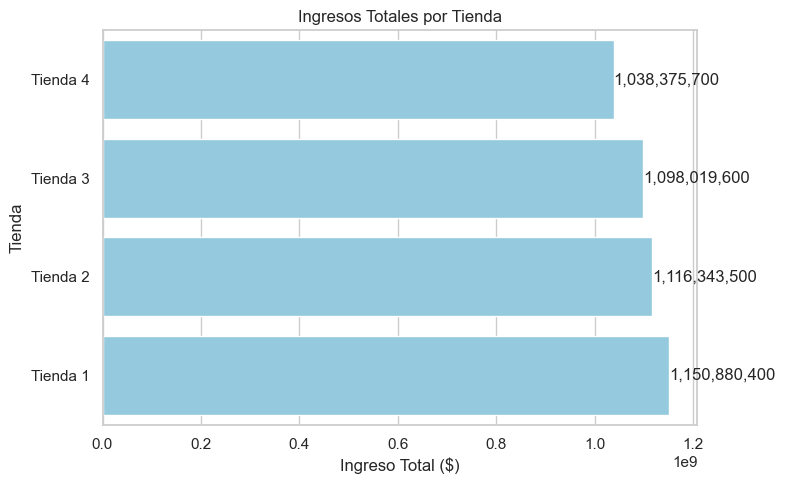

In [9]:
sns.set_theme(style="whitegrid")

comparativa_sorted = comparativa.sort_values("Ingreso Total")

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=comparativa_sorted,
    x="Ingreso Total",
    y="tienda",
    color="skyblue"
)

plt.title("Ingresos Totales por Tienda")
plt.xlabel("Ingreso Total ($)")
plt.ylabel("Tienda")

for i, v in enumerate(comparativa_sorted["Ingreso Total"]):
    ax.text(v, i, f"{v:,.0f}", va="center", ha="left")

plt.tight_layout()
plt.show()

# Ingreso total por lugar y tienda

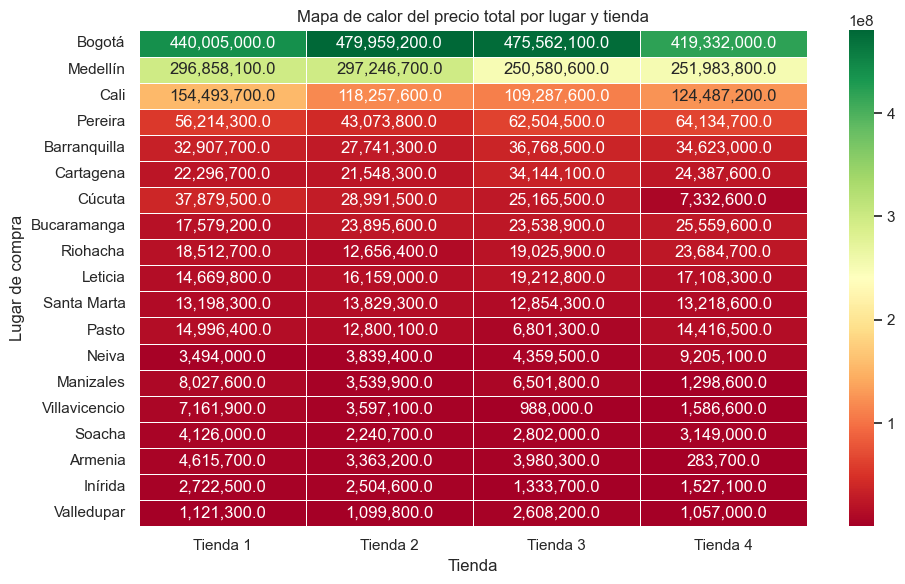

In [11]:
# Agrupar por lugar y tienda para sumar ingreso total
tabla = (
    df.groupby(['lugar_de_compra', 'tienda'])['precio']
      .sum()
      .reset_index()
)

# Calcular el total por lugar
totales_lugar = (
    tabla.groupby("lugar_de_compra")["precio"]
         .sum()
         .sort_values(ascending=False)   # orden descendente
)

# Convertir lugar_de_compra
tabla["lugar_de_compra"] = pd.Categorical(
    tabla["lugar_de_compra"],
    categories=totales_lugar.index,
    ordered=True
)

# Tabla pivote para heatmap
pivot = tabla.pivot(
    index='lugar_de_compra',
    columns='tienda',
    values='precio'
)

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=",",
    cmap="RdYlGn",
    linewidths=.5
)

plt.title("Mapa de calor del precio total por lugar y tienda")
plt.xlabel("Tienda")
plt.ylabel("Lugar de compra")
plt.tight_layout()
plt.show()

     tienda  Ingreso Total  Margen Total
0  Tienda 1  1,150,880,400 1,089,502,500
1  Tienda 2  1,116,343,500 1,056,858,400
2  Tienda 3  1,098,019,600 1,039,503,000
3  Tienda 4  1,038,375,700   983,058,300


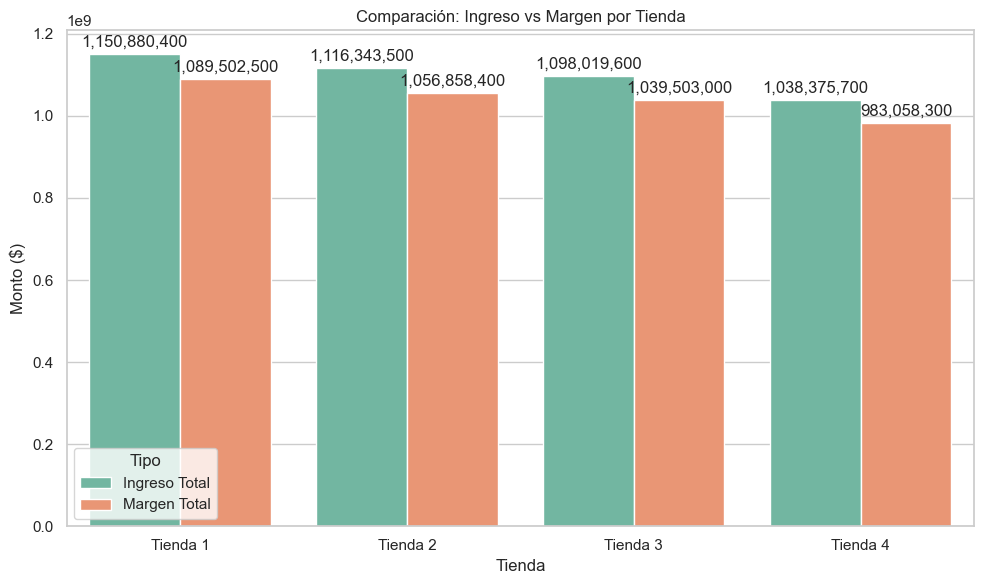

In [12]:
sns.set_theme(style="whitegrid")


df["precio"] = pd.to_numeric(df["precio"], errors="coerce")
df["costo_de_envio"] = pd.to_numeric(df["costo_de_envio"], errors="coerce")

# ================================
# Crear margen
# ================================
df["margen_bruto"] = df["precio"] - df["costo_de_envio"]

# ================================
# Agrupar por tienda: ingreso y margen
# ================================
comparativa = (
    df.groupby("tienda")
      .agg({
          "precio": "sum",
          "margen_bruto": "sum"
      })
      .rename(columns={
          "precio": "Ingreso Total",
          "margen_bruto": "Margen Total"
      })
      .reset_index()
)

comparativa_sorted = comparativa.sort_values("Ingreso Total", ascending=False)

print(comparativa_sorted)

# Transformar para seaborn
comparativa_melt = comparativa_sorted.melt(
    id_vars="tienda",
    value_vars=["Ingreso Total", "Margen Total"],
    var_name="Tipo",
    value_name="Valor"
)

# ================================
# Gráfico con separador de miles
# ================================
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=comparativa_melt,
    x="tienda",
    y="Valor",
    hue="Tipo",
    palette="Set2"
)

plt.title("Comparación: Ingreso vs Margen por Tienda")
plt.xlabel("Tienda")
plt.ylabel("Monto ($)")

# Etiquetas con separador de miles
for c in ax.containers:
    ax.bar_label(c, labels=[f"{v:,.0f}" for v in c.datavalues], padding=3)

plt.tight_layout()
plt.show()

# Análisis de calificación de clientes

In [13]:
# ===========================
# Calificación promedio por tienda
# ===========================
calif_por_tienda = df.groupby("tienda")["calificacion"].mean()

print("=== Calificación promedio por tienda ===")
print(calif_por_tienda.round(2))

# ===========================
# Distribución general de calificaciones (1 a 5)
# ===========================
dist = df["calificacion"].value_counts().sort_index()

print("\n=== Distribución de calificaciones (conteo) ===")
print(dist)

# ===========================
# % de calificaciones negativas (1 y 2) por tienda
# ===========================
df["negativa"] = df["calificacion"].isin([1])

negativas = df.groupby("tienda")["negativa"].mean() * 100

print("\n=== % de calificaciones negativas por tienda ===")
print(negativas.round(2))

=== Calificación promedio por tienda ===
tienda
Tienda 1   4
Tienda 2   4
Tienda 3   4
Tienda 4   4
Name: calificacion, dtype: float64

=== Distribución de calificaciones (conteo) ===
calificacion
1    1199
2     343
3     830
4    1813
5    5250
Name: count, dtype: int64

=== % de calificaciones negativas por tienda ===
tienda
Tienda 1   14
Tienda 2   12
Tienda 3   13
Tienda 4   13
Name: negativa, dtype: float64


# Análisis de vendedores

In [14]:
df["precio"] = pd.to_numeric(df["precio"], errors="coerce")

# Ingreso total por vendedor por tienda
ingreso_vendedor = (
    df.groupby(["vendedor"])["precio"]
      .sum()
      .sort_values(ascending=False)
)

print("=== Ranking de ingresos por vendedor y tienda ===")
print(ingreso_vendedor.head(20))

=== Ranking de ingresos por vendedor y tienda ===
vendedor
Felipe Santos     353,796,000
Izabela de León   350,342,400
Maria Alfonso     349,694,800
Juliana Costa     338,364,700
Pedro Gomez       313,350,900
Rafael Acosta     310,292,300
Juan Fernandez    308,562,100
Lucas Olivera     305,403,600
Camila Rivera     303,184,200
Beatriz Morales   302,695,600
Blanca Ramirez    299,586,600
Santiago Silva    293,418,200
Ángel Rodriguez   291,625,200
Mariana Herrera   283,302,600
Name: precio, dtype: float64


# Volumen de ventas por tienda

In [15]:
ventas_por_tienda = df.groupby("tienda")["producto"].count()

print("=== Cantidad de ventas por tienda ===")
print(ventas_por_tienda)

=== Cantidad de ventas por tienda ===
tienda
Tienda 1    2359
Tienda 2    2359
Tienda 3    2359
Tienda 4    2358
Name: producto, dtype: int64


# Ticket promedio por tienda

In [16]:
ticket_promedio = (
    df.groupby("tienda")["precio"]
      .mean()
      .round(2)
)

print("=== Ticket Promedio por tienda ===")
print(ticket_promedio)

=== Ticket Promedio por tienda ===
tienda
Tienda 1   487,868
Tienda 2   473,227
Tienda 3   465,460
Tienda 4   440,363
Name: precio, dtype: float64


# Ventas por mes y por tienda

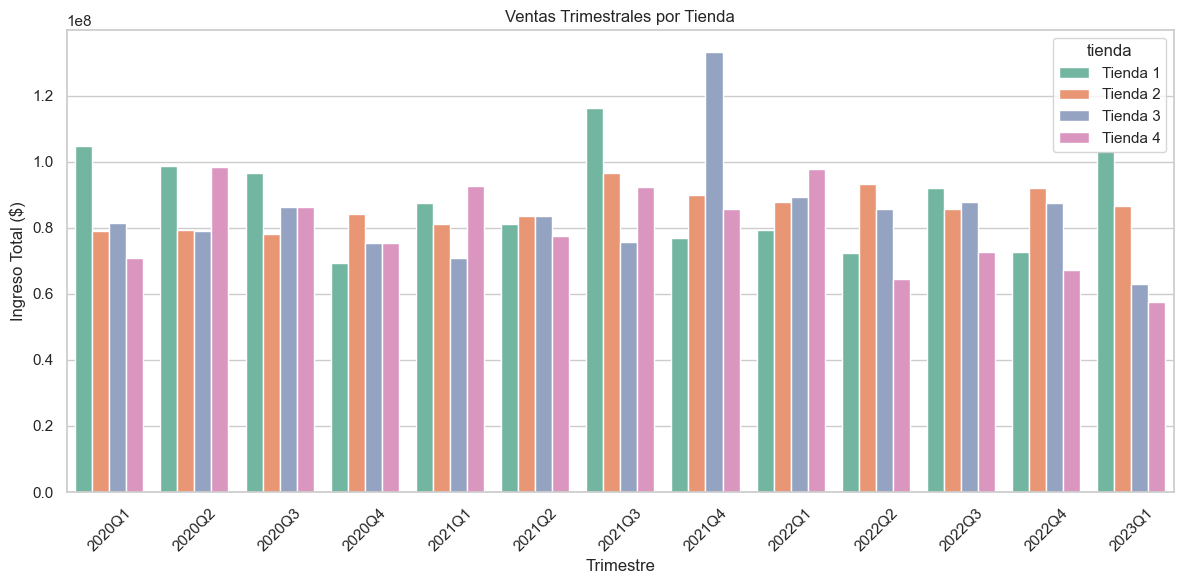

In [ ]:
df["fecha_de_compra"] = pd.to_datetime(
    df["fecha_de_compra"],
    format="%d/%m/%Y"
)

df["trimestre"] = df["fecha_de_compra"].dt.to_period("Q").astype(str)

trimestral = (
    df.groupby(["trimestre", "tienda"])["precio"]
      .sum()
      .reset_index()
)


plt.figure(figsize=(12,6))
sns.barplot(
    data=trimestral,
    x="trimestre",
    y="precio",
    hue="tienda",
    palette="Set2"
)

plt.title("Ventas Trimestrales por Tienda")
plt.xlabel("Trimestre")
plt.ylabel("Ingreso Total ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

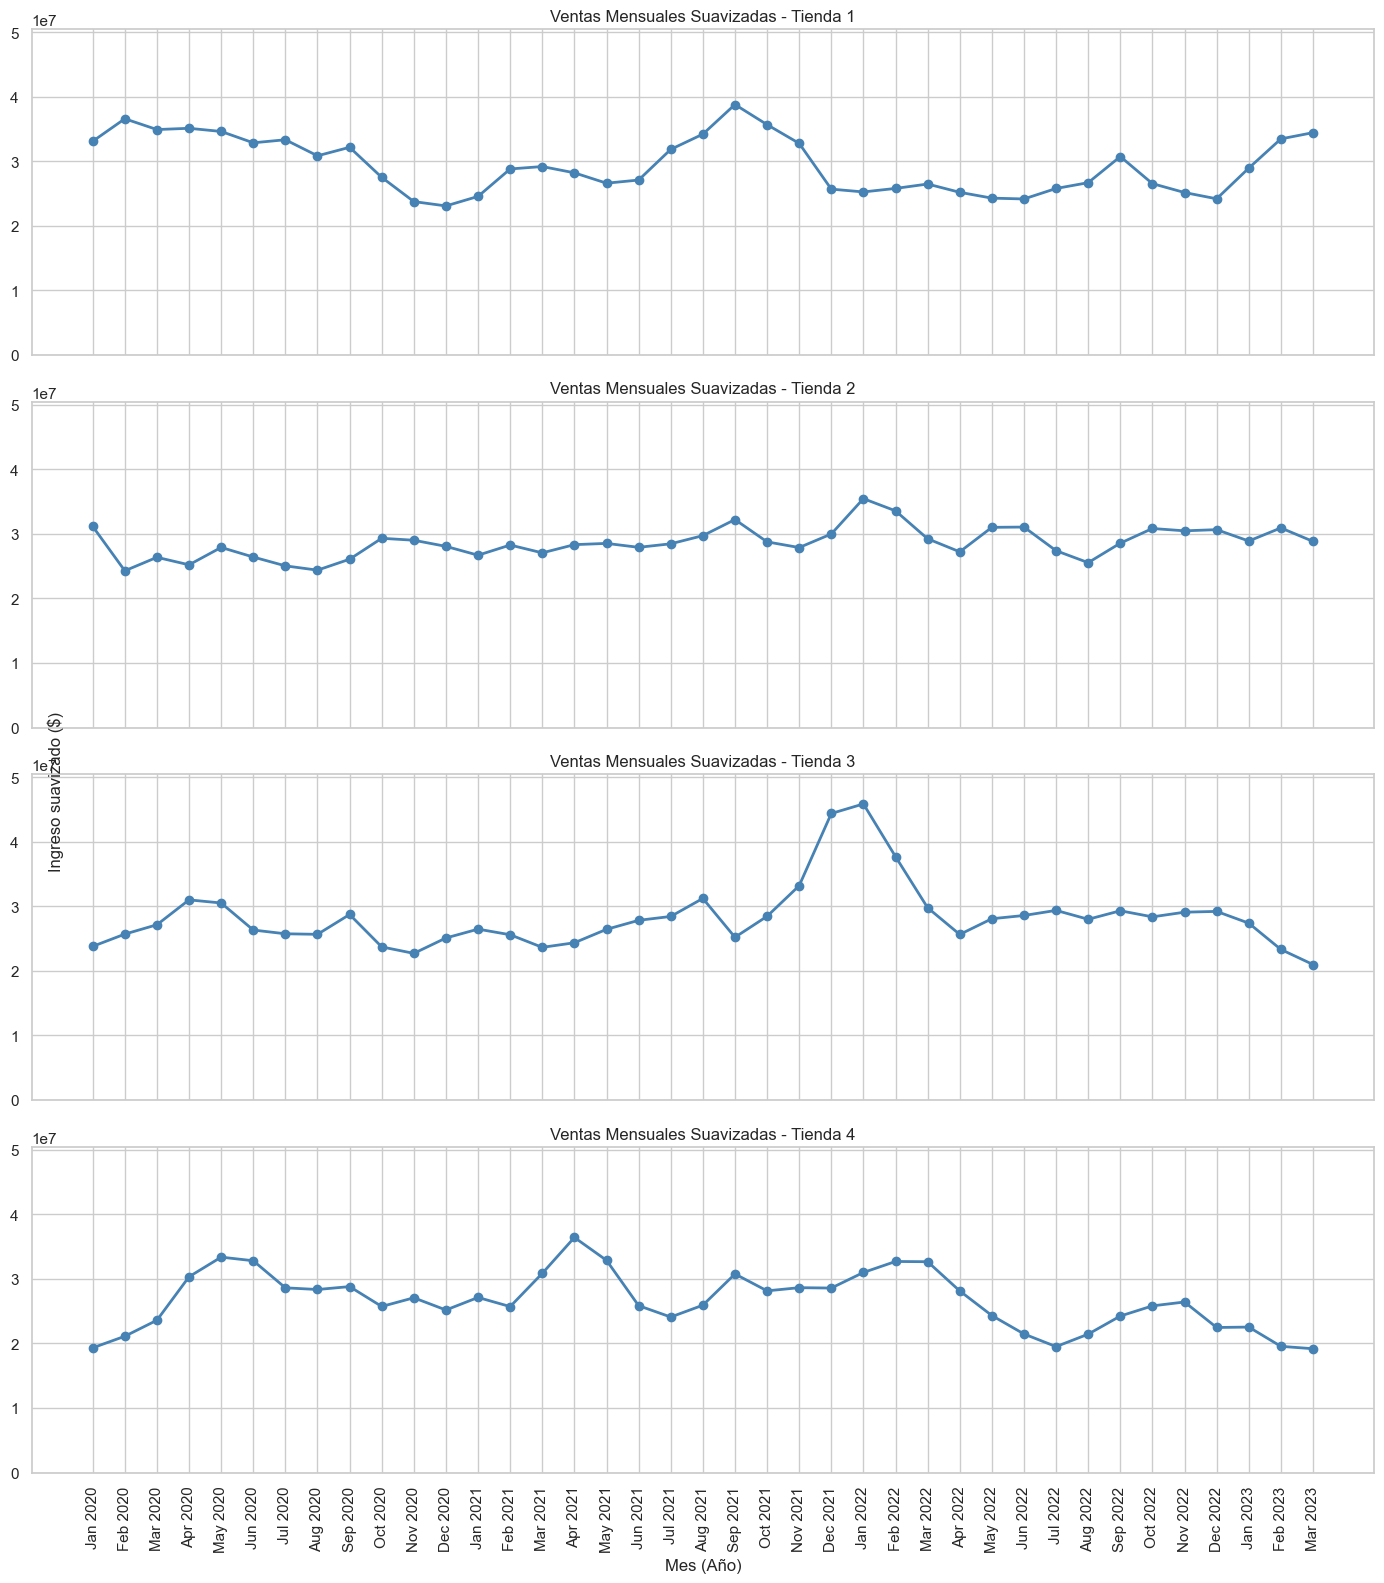

In [ ]:
sns.set_theme(style="whitegrid")

df["fecha_de_compra"] = pd.to_datetime(df["fecha_de_compra"], dayfirst=True, errors="coerce")

# Agrupar por mes
df["mes"] = df["fecha_de_compra"].dt.to_period("M").dt.to_timestamp()

pivot = (
    df.groupby(["mes", "tienda"])["precio"]
      .sum()
      .reset_index()
)

# ============================
# Suavizado mensual
# ============================
pivot["suavizado"] = (
    pivot.groupby("tienda")["precio"]
         .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# ============================
# Límite global del eje Y
# ============================
y_max = pivot["suavizado"].max() * 1.10

# Etiquetas de mes-año
pivot["mes_label"] = pivot["mes"].dt.strftime("%b %Y")   # Ej: Ene 2021

# ============================
# Graficar 4 líneas apiladas
# ============================
tiendas = pivot["tienda"].unique()

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True, sharey=True)

for i, tienda in enumerate(tiendas):
    data_t = pivot[pivot["tienda"] == tienda]

    axes[i].plot(
        data_t["mes_label"],
        data_t["suavizado"],
        marker="o",
        linewidth=2,
        color="steelblue"
    )

    axes[i].set_title(f"Ventas Mensuales Suavizadas - {tienda}")
    axes[i].set_ylim(0, y_max)
    axes[i].grid(True)
    axes[i].tick_params(axis="x", rotation=90)  # Mejor 90° para mes-año largos

axes[-1].set_xlabel("Mes (Año)")
fig.text(0.04, 0.5, "Ingreso suavizado ($)", va="center", rotation="vertical")

plt.tight_layout()
plt.show()